#### magic function

In [11]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    return

# module

In [24]:
## module
# data processing

# install pandas if not already installed
%pip install pandas

import pandas as pd
import numpy as np

# data preprocessing

# install scikit-learn if not already installed
%pip install scikit-learn

from sklearn.preprocessing import LabelEncoder

# data visualization

# install seaborn if not already installed
%pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 294.9/294.9 kB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# load data

In [14]:
df = pd.read_csv('.\\data\\Squadro_BGA_history.csv')

df.head()

,id,date,winner,loser,elo_winner,elo_loser,first_hand,conceded,record
0,655314007,2025-04-07 22:24:00,chickenheart0809,reika2001,157,126,chickenheart0809,False,r2y4r1y3r2y3r1y2r1y5r1y5r1y3r1y3r4y5r1y3r2y3r5...
1,651884826,2025-04-07 19:18:00,mad rid,izZziCOS,798,1,izZziCOS,False,y1r1y2r1y3r1y1r1y3r1y3r5y5r5y5r5y4r1y4r1y4r4y3...
2,655256642,2025-04-07 19:06:00,mino24,BeaM59,193,72,BeaM59,False,r5y4r5y4r5y4r4y5r5y3r3y3r3y4r5y4r5y4r5y4r4y4r3...
3,653819533,2025-04-07 17:26:00,MagoselvaggioHO,Alena2588,435,1,MagoselvaggioHO,False,r5y5r5y5r5y1r5y4r1y3r1y4r1y4r4y4r4y4r1y4r1y4r2...
4,655228842,2025-04-07 17:23:00,a_trex,Arony Pony,128,74,a_trex,False,r1y4r1y4r1y3r2y5r4y4r3y4r4y1r2y3r3y4r3y4r3y4r3...


# preprocessing

In [ ]:
# NaN values in each column
df.isna().sum()

id            0
date          0
winner        0
loser         0
elo_winner    0
elo_loser     0
first_hand    0
conceded      0
record        0
dtype: int64

## labeling

In [16]:
# set label encoders
winner_li = LabelEncoder()
loser_li = LabelEncoder()
user_li = LabelEncoder()

# fit label encoders
winner_li.fit(df['winner'])
loser_li.fit(df['loser'])

# check
print(f'winner_label_encoder_classes_nunique: \n{winner_li.classes_.shape[0]}')
print(f'loser_label_encoder_classes_nunique:  \n{loser_li.classes_.shape[0]}')

# combine classes
user_list = winner_li.classes_.tolist() + loser_li.classes_.tolist()
user_list = list(set(user_list))
user_li.classes_ = np.array(user_list)

# check
print(f'user_label_encoder_classes_nunique:  \n{user_li.classes_.shape[0]}')

winner_label_encoder_classes_nunique: 
2670


loser_label_encoder_classes_nunique:  
5283
user_label_encoder_classes_nunique:  
5732


In [17]:
temp_df = df.copy(deep=True)

# transform label encoders
df['winner'] = user_li.transform(temp_df['winner'])
df['loser'] =  user_li.transform(temp_df['loser'])
df['first_hand'] = user_li.transform(temp_df['first_hand'])

# check
df.head(5)

,id,date,winner,loser,elo_winner,elo_loser,first_hand,conceded,record
0,655314007,2025-04-07 22:24:00,3824,5264,157,126,3824,False,r2y4r1y3r2y3r1y2r1y5r1y5r1y3r1y3r4y5r1y3r2y3r5...
1,651884826,2025-04-07 19:18:00,3614,3851,798,1,3851,False,y1r1y2r1y3r1y1r1y3r1y3r5y5r5y5r5y4r1y4r1y4r4y3...
2,655256642,2025-04-07 19:06:00,4553,2294,193,72,2294,False,r5y4r5y4r5y4r4y5r5y3r3y3r3y4r5y4r5y4r5y4r4y4r3...
3,653819533,2025-04-07 17:26:00,1584,2213,435,1,1584,False,r5y5r5y5r5y1r5y4r1y3r1y4r1y4r4y4r4y4r1y4r1y4r2...
4,655228842,2025-04-07 17:23:00,3142,4681,128,74,3142,False,r1y4r1y4r1y3r2y5r4y4r3y4r4y1r2y3r3y4r3y4r3y4r3...


In [18]:
# check data types
display(df.info())
display(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24811 entries, 0 to 24810
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          24811 non-null  int64 
 1   date        24811 non-null  object
 2   winner      24811 non-null  int64 
 3   loser       24811 non-null  int64 
 4   elo_winner  24811 non-null  int64 
 5   elo_loser   24811 non-null  int64 
 6   first_hand  24811 non-null  int64 
 7   conceded    24811 non-null  bool  
 8   record      24811 non-null  object
dtypes: bool(1), int64(6), object(2)
memory usage: 1.5+ MB


None

id            24811
date          24641
winner         2670
loser          5283
elo_winner      792
elo_loser       712
first_hand     4409
conceded          2
record        24807
dtype: int64

In [22]:
# drop
df = df.drop(columns=['date', 'id'])
df.columns

Index(['winner', 'loser', 'elo_winner', 'elo_loser', 'first_hand', 'conceded',
       'record'],
      dtype='object')

# EDA

In [26]:
# setting seaborn style
sns.set_color_codes('colorblind')
sns.set_style('whitegrid')
sns.set_context('notebook')

In [36]:
temp_df = df[['elo_winner', 'elo_loser']].copy(deep=True)
temp_df['elo_diff'] = temp_df['elo_winner'] - temp_df['elo_loser']

temp_df.describe()

,elo_winner,elo_loser,elo_diff
count,24811.000000,24811.000000,24811.000000
mean,289.901818,110.622748,179.279070
std,210.190488,130.382641,216.899958
min,1.000000,0.000000,-691.000000
25%,120.000000,1.000000,30.000000
50%,221.000000,97.000000,121.000000
75%,445.000000,133.000000,315.000000
max,812.000000,795.000000,811.000000


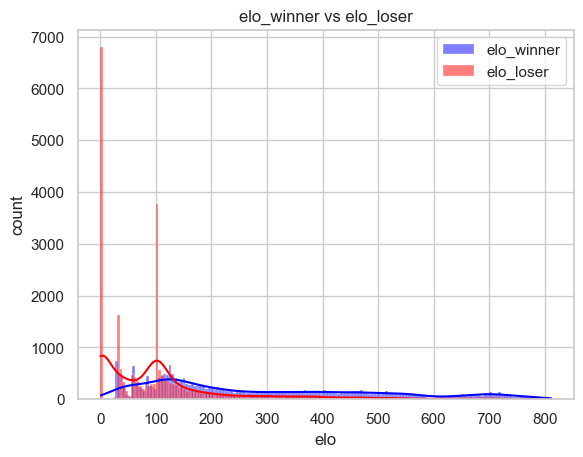

In [34]:
sns.histplot(data=df, x='elo_winner',
             color='blue', label='elo_winner',
             alpha=0.5, kde=True, bins=160)
sns.histplot(data=df, x='elo_loser',
             color='red',label='elo_loser', 
             alpha=0.5, kde=True, bins=160)

plt.xlabel('elo')
plt.ylabel('count')
plt.title('elo_winner vs elo_loser')

plt.legend()
plt.show()

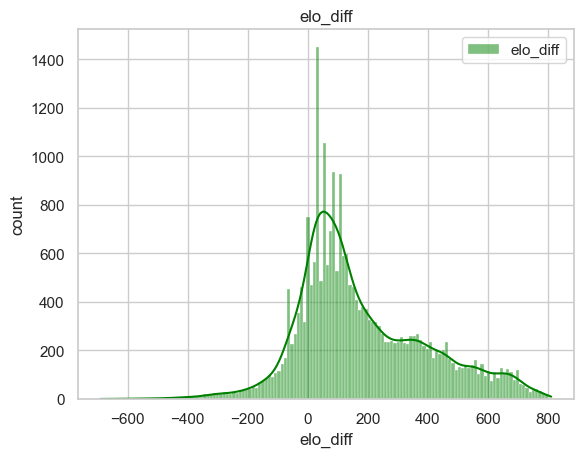

In [40]:
sns.histplot(data=temp_df, x='elo_diff',
             color='green', label='elo_diff',
             alpha=0.5, kde=True, bins=140)

plt.xlabel('elo_diff')
plt.ylabel('count')
plt.title('elo_diff')

plt.legend()
plt.show()